# [Computational Social Science] Project 4: Unsupervised Learning

**Enter your Name:**Yidan Tang

*Semester:* Fall 2025

## Data Description and Preprocessing

For this project, you will explore data from the [National Health and Nutrition Examination Survey](https://www.kaggle.com/cdc/national-health-and-nutrition-examination-survey?select=questionnaire.csv). NHANES is a unique study that combines survey methodology with in-person medical examinations to create a dataset with demographic information, health indicators, and health outcomes.

We start by importing the data and doing some preliminary preprocessing for you. We import some libraries that will be helpful as well. 'SEQN' is the ID number for each respondent, and 'HSD010' will be our target outcome. [HSD010](https://wwwn.cdc.gov/Nchs/Nhanes/2013-2014/HSQ_H.htm#HSD010) asks for the respondent's self reported health condition, which can range from "excellent" to "poor."

In [12]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
sns.set_style("darkgrid")
from sklearn.model_selection import train_test_split

In [13]:
# Load nhanes data
nhanes = pd.read_csv('nhanes.csv')
# Get the ID numbers for each observation (seqn)
seqn = nhanes['SEQN']
# Get the target, "self-reported health condition," HSD010
hsd010 = nhanes['HSD010']
# Drop SEQN from the dataframe and then apply the standard scaler
nhanes = nhanes.drop(['SEQN', 'HSD010'], axis = 1)
nhanes_scaled = pd.DataFrame(StandardScaler().fit_transform(nhanes),
                             columns = nhanes.columns)
# Add the ID and target back in
nhanes_scaled['SEQN'] = seqn
nhanes_scaled['HSD010'] = hsd010
nhanes_scaled = nhanes_scaled.set_index('SEQN')
nhanes_scaled.head()

,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,DR1MNRSP,DR1HELPD,DBQ095Z,...,OHQ770,OHQ845,PAAQUEX,SMQ860,SMQ870,SMQ872,SMQ874,SMQ878,SMAQUEX.x,HSD010
SEQN,,,,,,,,,,,,,,,,,,,,,
73568,0.0,2.034312,0.0,0.324834,-0.393906,1.085853,-0.194202,-0.057306,0.128246,-0.189513,...,0.383802,-0.646584,-0.484200,1.125008,0.0,-2.081666,1.087115,1.463404,0.612440,1
73576,0.0,0.261930,0.0,-3.078499,0.568251,0.634362,-0.194202,-0.057306,0.128246,0.080373,...,0.383802,-1.539259,-0.484200,1.125008,0.0,-2.081666,1.087115,-0.683338,-1.632812,1
73579,0.0,0.728346,0.0,0.324834,1.530407,-1.623092,-0.194202,-0.057306,0.128246,-0.189513,...,0.383802,-1.539259,2.065262,-0.888883,0.0,0.480384,-0.919866,-0.683338,-1.632812,2
73581,0.0,-0.857470,0.0,0.324834,0.480782,1.085853,-0.194202,-0.057306,0.128246,0.080373,...,0.383802,-0.646584,-0.484200,1.125008,0.0,0.480384,-0.919866,-0.683338,0.612440,2
73584,0.0,0.495138,0.0,0.324834,0.305844,-1.623092,-0.194202,-0.057306,0.128246,0.080373,...,-2.605509,0.246091,2.065262,1.125008,0.0,0.480384,-0.919866,1.463404,-1.632812,3


## Plots

Let's take a look at the data. Below we visualize boxplots of family income to federal poverty line ratio ('INDFMPIR') and self-reported health condition. Notice how there are some clear patterns (the lower the ratio, the lower reported health condition), but it's not a perfect separation. We have 240+ features in our dataset, and we likely have several features in our dataset that highly correlate with our family income-poverty line ratio measure - PCA will help us simplify these.

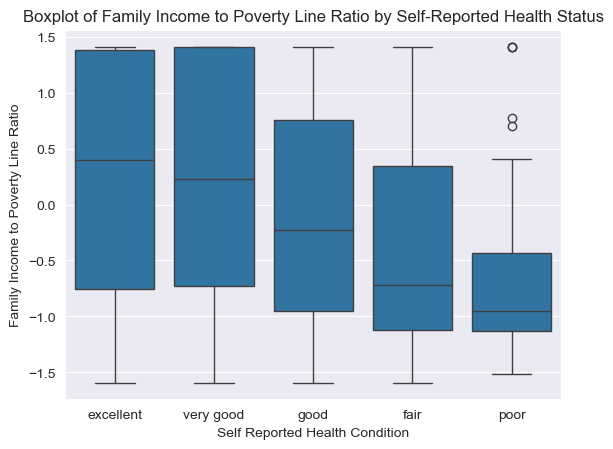

In [14]:
# Create a binary version of hsd010 where 1-3 are "good" and 4-5 are "poor"
nhanes_scaled['HSD010_binary'] = hsd010_binary = nhanes_scaled['HSD010'].replace(
    [1, 2, 3, 4, 5], ['good', 'good', 'good', 'poor', 'poor']) 
# Recode the original hsd010 with the string labels
nhanes_scaled['HSD010'] = nhanes_scaled['HSD010'].replace(
    [1, 2, 3, 4, 5], ['excellent', 'very good', 'good', 'fair', 'poor'])
# Boxplot of hsd010
ax = sns.boxplot(x = 'HSD010', y = 'INDFMPIR', data = nhanes_scaled)
ax.set(xlabel = "Self Reported Health Condition",
      ylabel = "Family Income to Poverty Line Ratio")
ax.set_title("Boxplot of Family Income to Poverty Line Ratio by Self-Reported Health Status")
plt.show()

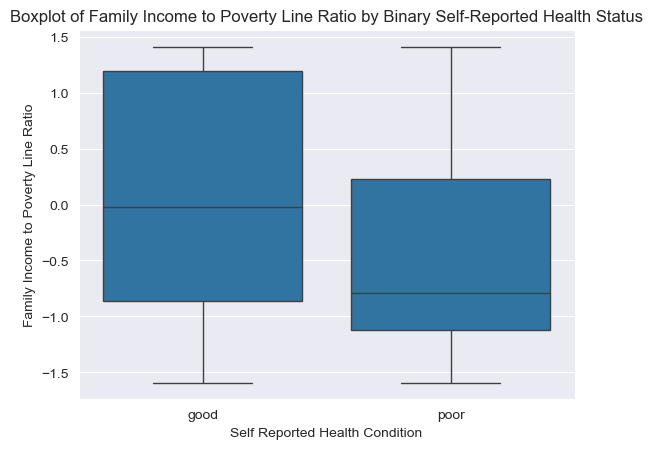

In [15]:
# Boxplot of hsd010_binary
ax = sns.boxplot(x = 'HSD010_binary', y = 'INDFMPIR', data = nhanes_scaled)
ax.set(xlabel = "Self Reported Health Condition",
      ylabel = "Family Income to Poverty Line Ratio")
ax.set_title("Boxplot of Family Income to Poverty Line Ratio by Binary Self-Reported Health Status")
plt.show()

Family income also is not necessarily well correlated with measured health outcomes. See below where we look at the relationship between Body Mass Index (BMI) and the family income-poverty line ratio, and shade points by self-reported health condition. It's hard to find a clear pattern - this is where clustering may come in handy. 

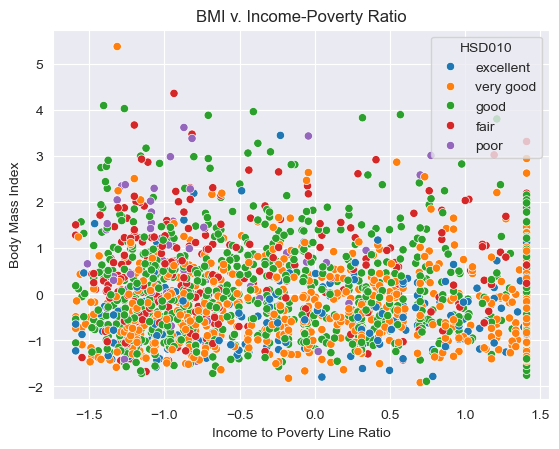

In [16]:
ax = sns.scatterplot(x = "INDFMPIR", y = "BMXBMI", hue = "HSD010", palette = "tab10", data = nhanes_scaled)
ax.set(xlabel = "Income to Poverty Line Ratio",
      ylabel = "Body Mass Index")
ax.set_title("BMI v. Income-Poverty Ratio")
plt.show()

Before we move to working on unsupervised methods, we'll drop our target variables again:

In [17]:
nhanes_scaled = nhanes_scaled.drop(['HSD010', 'HSD010_binary'], axis = 1)

## Principal Component Analysis

Conduct a Principal Component Analysis (PCA) of the nhanes data. The data has already been prepared for you, so you can work directly on nhanes_scaled. Be sure to do the following:

- Choose the number of components and provide 1-2 sentences about your choice of the number of components. 
- Plot a barplot of the variation explained by each component. *Hint*: look at the attributes associated with your model. 
- Choose how many components you will use to fit a supervised learning model and provide 1-2 sentences to explain that choice.
- Plot a 2D scatterplot of the first two components and provide 1-2 sentences analyzing the plot.

### Train PCA and Discuss Number of Components

In [18]:
# Fit PCA with all components first
pca = PCA()
pca.fit(nhanes_scaled)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

I first fit PCA using all available components in order to examine how variance is distributed across dimensions. This allows us to make an informed decision about how many components are needed to capture the majority of the information in the dataset.

### Barplot of Components

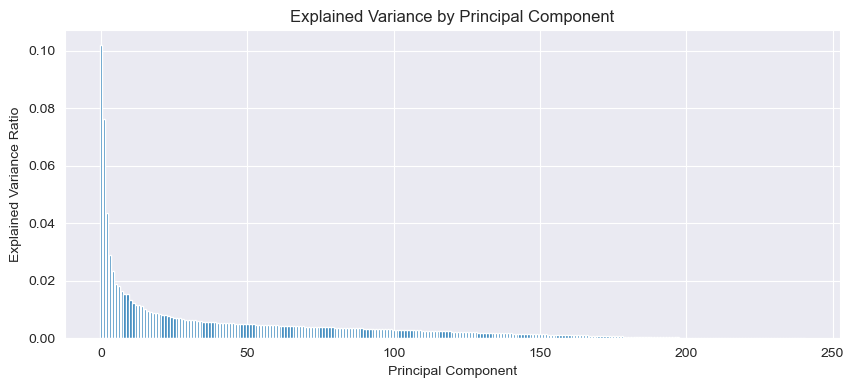

In [19]:
plt.figure(figsize=(10, 4))
plt.bar(range(len(explained_variance)), explained_variance)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Principal Component")
plt.show()

The barplot shows that the first several principal components explain a substantially larger proportion of the variance, while later components contribute only marginal gains. This suggests that the original high-dimensional feature space can be effectively reduced with limited information loss.

### How many components will you use to fit a supervised learning model?

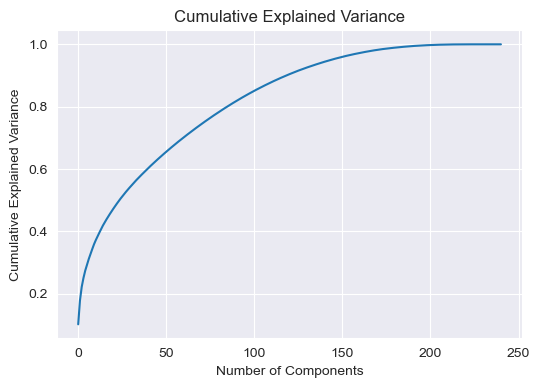

In [20]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(6, 4))
plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.show()

In [21]:
n_components = np.where(cumulative_variance >= 0.75)[0][0] + 1
n_components

np.int64(73)

I choose to retain approximately N principal components, which together explain about 75% of the total variance. This represents a balance between reducing dimensionality and preserving sufficient information for downstream supervised learning.

### 2D Scatterplot of the first two components

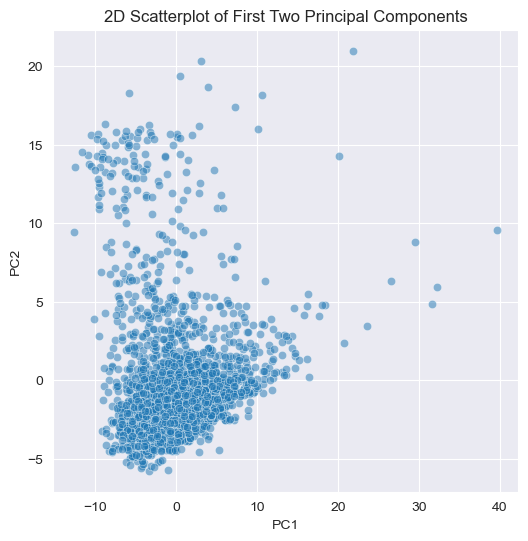

In [22]:
# Transform data using PCA
pca_2d = PCA(n_components=2)
components_2d = pca_2d.fit_transform(nhanes_scaled)

pca_df = pd.DataFrame(
    components_2d,
    columns=['PC1', 'PC2'],
    index=nhanes_scaled.index
)

plt.figure(figsize=(6, 6))
sns.scatterplot(x='PC1', y='PC2', data=pca_df, alpha=0.5)
plt.title("2D Scatterplot of First Two Principal Components")
plt.show()


The first two principal components reveal substantial overlap among observations, with no clear separation into distinct groups. This suggests that while PCA effectively reduces dimensionality, additional structure—such as clustering—may be needed to uncover latent groupings relevant to health outcomes.

## K-Means

- Choose a clustering algorithm and explain it in 1-2 sentences.
- Cluster the nhanes data. Detail any choice you need to make with regards to number of clusters, and how you arrived at that choice. For instance, you might use the [elbow method](https://en.wikipedia.org/wiki/Elbow_method_(clustering)) if you choose k-means.
- Plot your clusters on top of BMI v. Income Poverty Ratio Plot. Describe what you see in 1-2 sentences.
- Retrain the clustering algorithm, but this time use your PCA results instead of the original dataframe. Plot the clusters on top of the 2D PCA scatterplot from the previous step. Describe your results in 1-2 sentences.

### Choose a Clustering Algorithm

I use K-means clustering because it is a simple and widely used unsupervised algorithm that partitions observations into groups by minimizing within-cluster variance. It is well suited for high-dimensional, standardized data such as the NHANES dataset.

### Cluster nhanes

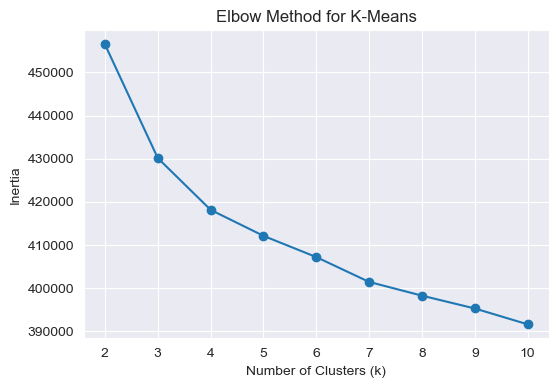

In [27]:
# Elbow method to choose number of clusters
inertias = []

K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(nhanes_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()


In [29]:
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(nhanes_scaled)

nhanes_clusters = nhanes_scaled.copy()
nhanes_clusters['cluster'] = cluster_labels


Using the elbow method, I select k=3 clusters, as the reduction in inertia begins to level off beyond this point. This suggests that three clusters provide a reasonable balance between model simplicity and explanatory power.

### Plot your clusters on top of the BMI v. Income Poverty Ratio Plot

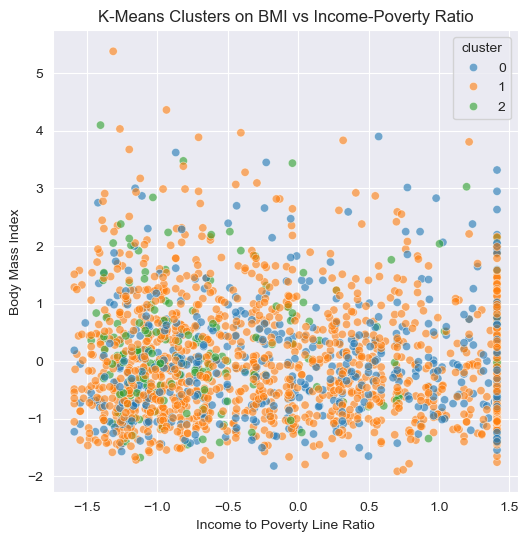

In [30]:
plt.figure(figsize=(6,6))
sns.scatterplot(
    x="INDFMPIR",
    y="BMXBMI",
    hue="cluster",
    palette="tab10",
    data=nhanes_clusters,
    alpha=0.6
)

plt.xlabel("Income to Poverty Line Ratio")
plt.ylabel("Body Mass Index")
plt.title("K-Means Clusters on BMI vs Income-Poverty Ratio")
plt.show()


When visualized in BMI–income space, the clusters show substantial overlap, with no clear separation along either dimension alone. This suggests that clustering is capturing multidimensional patterns beyond what can be observed using only BMI and income.

### Retrain the clustering algorithm on PCA components and plot clusters on your 2D scatter

In [31]:
pca_reduced = PCA(n_components=n_components)
nhanes_pca = pca_reduced.fit_transform(nhanes_scaled)

kmeans_pca = KMeans(n_clusters=3, random_state=42)
pca_clusters = kmeans_pca.fit_predict(nhanes_pca)


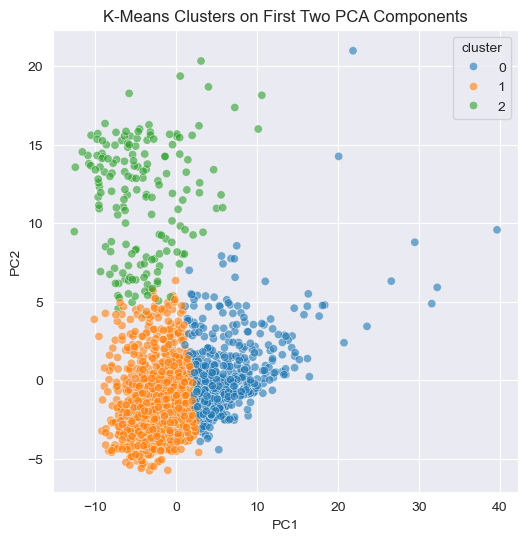

In [32]:
pca_plot_df = pd.DataFrame(
    nhanes_pca[:, :2],
    columns=['PC1', 'PC2'],
    index=nhanes_scaled.index
)
pca_plot_df['cluster'] = pca_clusters

plt.figure(figsize=(6,6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='tab10',
    data=pca_plot_df,
    alpha=0.6
)

plt.title("K-Means Clusters on First Two PCA Components")
plt.show()


Clustering in the PCA-reduced space produces more compact and structured groupings in the first two principal components. This indicates that PCA helps remove noise and redundancy, making underlying cluster structure more apparent.

## Neural Network

Now we are ready to predict! Do the following:

- Choose either HSD010 or HSD010\_binary as your target outcome.  
- Train a neural network using the original features. Much of the code to train a basic neural net has been set up for you, but you will need to fill in a couple of missing pieces.
- Train a neural network using only your PCA components as features.
- Train a neural network using your PCA components and the predicted class membership from your clustering algorithm as features.
- Compare and contrast how well each algorithm did. Which featurization technique would you pick and why?

Below we provide a template for training a neural network. Use this template for training on the original features, on the PCA components, and the PCA components + the predicted classes from your clusters.

### Neural Network on Original Features

In [43]:
# partition data
# -----------
y = hsd010_binary.map({'good': 0, 'poor': 1}).astype(int) # either hsd010 or hsd010_binary, may need to convert to numeric if it isn't already 
X = nhanes_scaled.copy() # drop out any columns that aren't features

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size = .25, 
                                                    random_state = 10)

In [44]:
# load libraries
# -----------
import keras
from keras.utils import to_categorical

num_classes = 2
# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test,  num_classes)
num_classes = y_test.shape[1]

In [45]:
# create neural network model
# -----------
model = Sequential()

model.add(Dense(64, input_dim=X_train.shape[1], kernel_initializer='he_normal', activation='relu'))

model.add(Dense(32, kernel_initializer='he_normal', activation='relu'))
model.add(Dense(2, activation='softmax'))

## Add any additional layers you wish here

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, batch_size=32, verbose=1)

loss_orig, acc_orig = model.evaluate(X_test, y_test, verbose=0)
print("Original Features Test Accuracy:", acc_orig)

Epoch 1/30


/opt/anaconda3/envs/csslab/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7125 - loss: 0.6309 - val_accuracy: 0.8488 - val_loss: 0.4417
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 729us/step - accuracy: 0.8611 - loss: 0.3468 - val_accuracy: 0.8333 - val_loss: 0.4212
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 707us/step - accuracy: 0.8947 - loss: 0.2771 - val_accuracy: 0.8508 - val_loss: 0.3896
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 702us/step - accuracy: 0.9199 - loss: 0.2271 - val_accuracy: 0.8547 - val_loss: 0.3871
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 716us/step - accuracy: 0.9302 - loss: 0.1883 - val_accuracy: 0.8643 - val_loss: 0.3870
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 731us/step - accuracy: 0.9516 - loss: 0.1541 - val_accuracy: 0.8682 - val_loss: 0.3937
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 705us/step - accuracy: 0.9625 - loss: 0.1266 - val_accuracy: 0.8605 - val_loss: 0.4035
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step - accuracy: 0.9690 - loss: 0.1047 - val_accuracy: 0.8527 - val_lo

### Neural Network on Principal Components

In [46]:
pca_reduced = PCA(n_components=n_components)
X_pca = pca_reduced.fit_transform(nhanes_scaled)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.25, random_state=10, stratify=y
)

num_classes = 2
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes)

model_pca = Sequential()
model_pca.add(Dense(64, input_dim=X_train.shape[1], kernel_initializer='he_normal', activation='relu'))
model_pca.add(Dropout(0.3))
model_pca.add(Dense(32, kernel_initializer='he_normal', activation='relu'))
model_pca.add(Dropout(0.3))
model_pca.add(Dense(num_classes, activation='softmax'))

model_pca.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_pca = model_pca.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=30, batch_size=32, verbose=0
)

loss_pca, acc_pca = model_pca.evaluate(X_test, y_test_cat, verbose=0)
print("PCA Features Test Accuracy:", acc_pca)


/opt/anaconda3/envs/csslab/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


PCA Features Test Accuracy: 0.8643410801887512


### Neural Network on Principal Components + Cluster Membership

In [47]:
# one-hot encode cluster membership (k=3)
cluster_onehot = keras.utils.to_categorical(pca_clusters, num_classes=3)

# concatenate PCA features + cluster one-hot
X_pca_cluster = np.hstack([X_pca, cluster_onehot])

X_train, X_test, y_train, y_test = train_test_split(
    X_pca_cluster, y, test_size=0.25, random_state=10, stratify=y
)

num_classes = 2
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes)

model_pca_cluster = Sequential()
model_pca_cluster.add(Dense(64, input_dim=X_train.shape[1], kernel_initializer='he_normal', activation='relu'))
model_pca_cluster.add(Dropout(0.3))
model_pca_cluster.add(Dense(32, kernel_initializer='he_normal', activation='relu'))
model_pca_cluster.add(Dropout(0.3))
model_pca_cluster.add(Dense(num_classes, activation='softmax'))

model_pca_cluster.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_pca_cluster = model_pca_cluster.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=30, batch_size=32, verbose=0
)

loss_pca_cluster, acc_pca_cluster = model_pca_cluster.evaluate(X_test, y_test_cat, verbose=0)
print("PCA + Cluster Test Accuracy:", acc_pca_cluster)


/opt/anaconda3/envs/csslab/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


PCA + Cluster Test Accuracy: 0.8585271239280701


In [48]:
print("Summary")
print("Original:", acc_orig)
print("PCA:", acc_pca)
print("PCA + Cluster:", acc_pca_cluster)

Summary
Original: 0.8488371968269348
PCA: 0.8643410801887512
PCA + Cluster: 0.8585271239280701


Among the three feature representations, the neural network trained on PCA components achieved the highest test accuracy (0.864), compared to the original feature model (0.849) and the PCA plus cluster membership model (0.859). This indicates that dimensionality reduction via PCA improves generalization by filtering out noisy and redundant variables. Although cluster membership introduces an explicit grouping structure, it does not further enhance performance beyond PCA alone, suggesting that clustering information is largely encoded within the principal components. Based on these results, PCA-only features provide the most effective and parsimonious representation for predicting self-reported health outcomes.

## Discussion Questions

1. In your own words, what is the difference between PCA and clustering?

PCA is mainly used to reduce the number of features by combining many variables into a smaller set of components that capture most of the variation in the data. In this assignment, PCA helped compress the original NHANES variables into fewer dimensions while keeping most of the information.

Clustering, on the other hand, is used to group observations. In this assignment, K-means was used to group individuals into clusters based on similarity, rather than reducing the number of features.

2. Did you notice any advantages to combining PCA and clustering? If so, what do you think they were? If not, why do you think you didn't see any gains from this combination?

In this assignment, combining PCA and clustering helped make the clusters easier to see. When clustering was applied directly to the original data, the clusters overlapped heavily in the BMI vs. income plot. After applying PCA, the clusters in the PCA space appeared more compact and structured.

This suggests that PCA removed noise and redundant information, which made the clustering results clearer, even though it did not dramatically improve prediction accuracy.

3. How can unsupervised techniques help with downstream supervised learning tasks when working with "big data?"

In this assignment, unsupervised methods helped simplify the data before prediction. PCA reduced the number of features while keeping most of the variation, which made the neural network easier to train and slightly improved accuracy. Clustering helped explore the structure of the data, even though it did not strongly improve prediction.

These results show that unsupervised techniques can help simplify complex datasets and highlight useful patterns before training supervised models, especially when working with high-dimensional data like NHANES.